In [ ]:
# >>> repo path setup (auto-added during reorg; keeps this notebook runnable from notebooks/) <<<
import os, sys
_p = os.getcwd()
while not os.path.isdir(os.path.join(_p, 'src')) and os.path.dirname(_p) != _p:
    _p = os.path.dirname(_p)
os.chdir(_p)
sys.path.insert(0, os.path.join(_p, 'src'))
# <<< end repo path setup >>>

In [1]:
%load_ext autoreload
%autoreload 2

In [16]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from pathlib import Path

from utils.vae import VanillaVAE
from utils.project_plots import plot_2d, configure_plot_settings

In [17]:
configure_plot_settings()

### Load Data

In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [44]:
path = Path('/net/vision/scr2/haipeng/FWI-HMC-Revision/')
train_data = np.load(path/'model2D/sa_prior_time25_samples_64x64_train.npy')
val_data   = np.load(path/'model2D/sa_prior_time25_samples_64x64_val.npy')
train_data = torch.tensor(train_data).float()
val_data   = torch.tensor(val_data).float()

print(f"Train data shape: {train_data.shape}, min: {train_data.min()}, max: {train_data.max()}")
print(f"Val   data shape: {val_data.shape},   min: {val_data.min()},   max: {val_data.max()}")

Train data shape: torch.Size([7800, 1, 64, 64]), min: 0.0, max: 0.5573965311050415
Val   data shape: torch.Size([200, 1, 64, 64]),   min: 0.0,   max: 0.5320130586624146


In [45]:
dx, dz = 5.0, 5.0 
nz_res, nx_res = 15, 179
res_x = np.arange(nx_res) * dx + (200-90) * dx
res_z = np.arange(nz_res) * dx + 260 * dx

extent=[res_x[0]/1000, res_x[-1]/1000, res_z[-1]/1000, res_z[0]/1000]

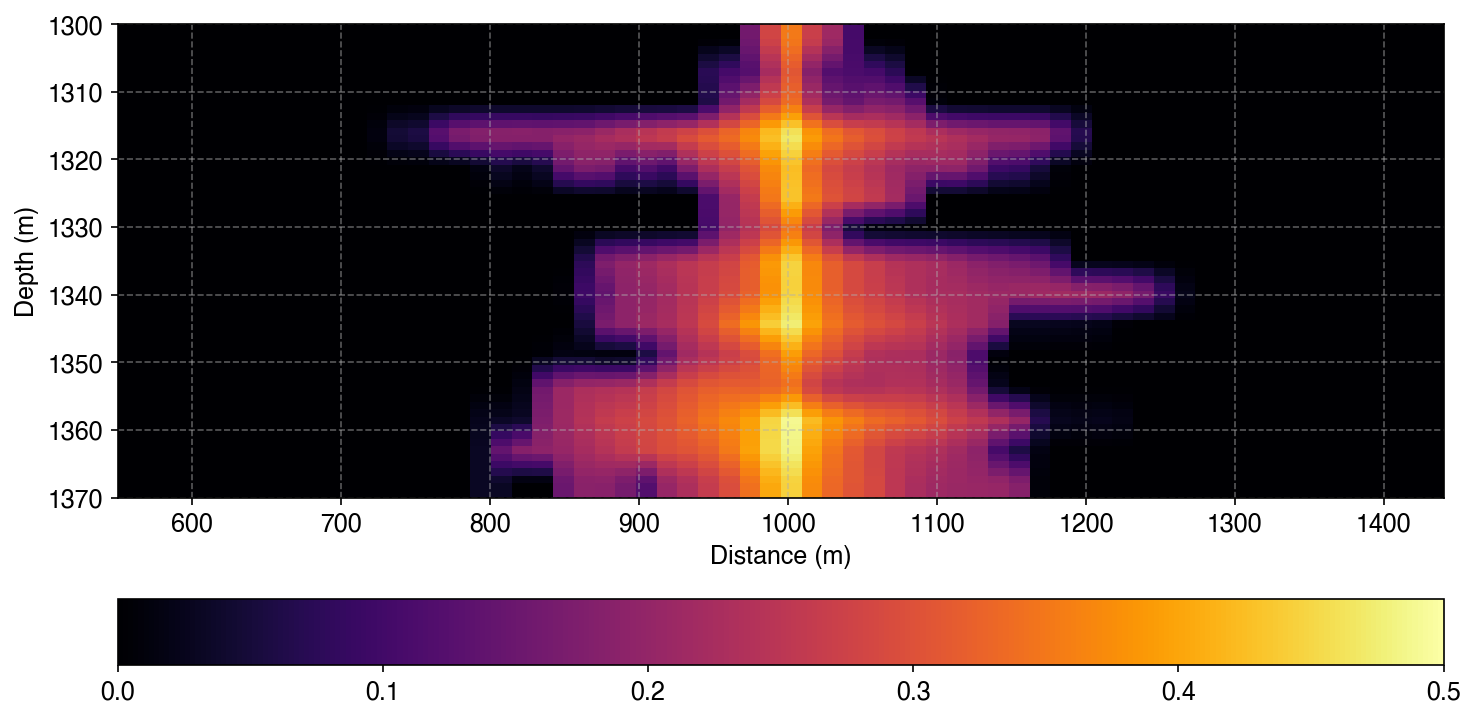

In [46]:
plot_2d(res_x, res_z, val_data[10].squeeze(), vmin=0, vmax=0.5, cmap='inferno')

### Evaluate Models

In [57]:
latent_dims  = [64, 128, 256]
kld_weights  = [5e-5, 1.5e-5, 5e-7]
in_channels = 1
cmap = "inferno"

torch.manual_seed(2222)

idx = 130
CO2_true = val_data[idx].to(device).unsqueeze(0)
CO2_true.shape

torch.Size([1, 1, 64, 64])

In [58]:
val_data.shape

torch.Size([200, 1, 64, 64])

/tmp/ipykernel_33381/3582043216.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


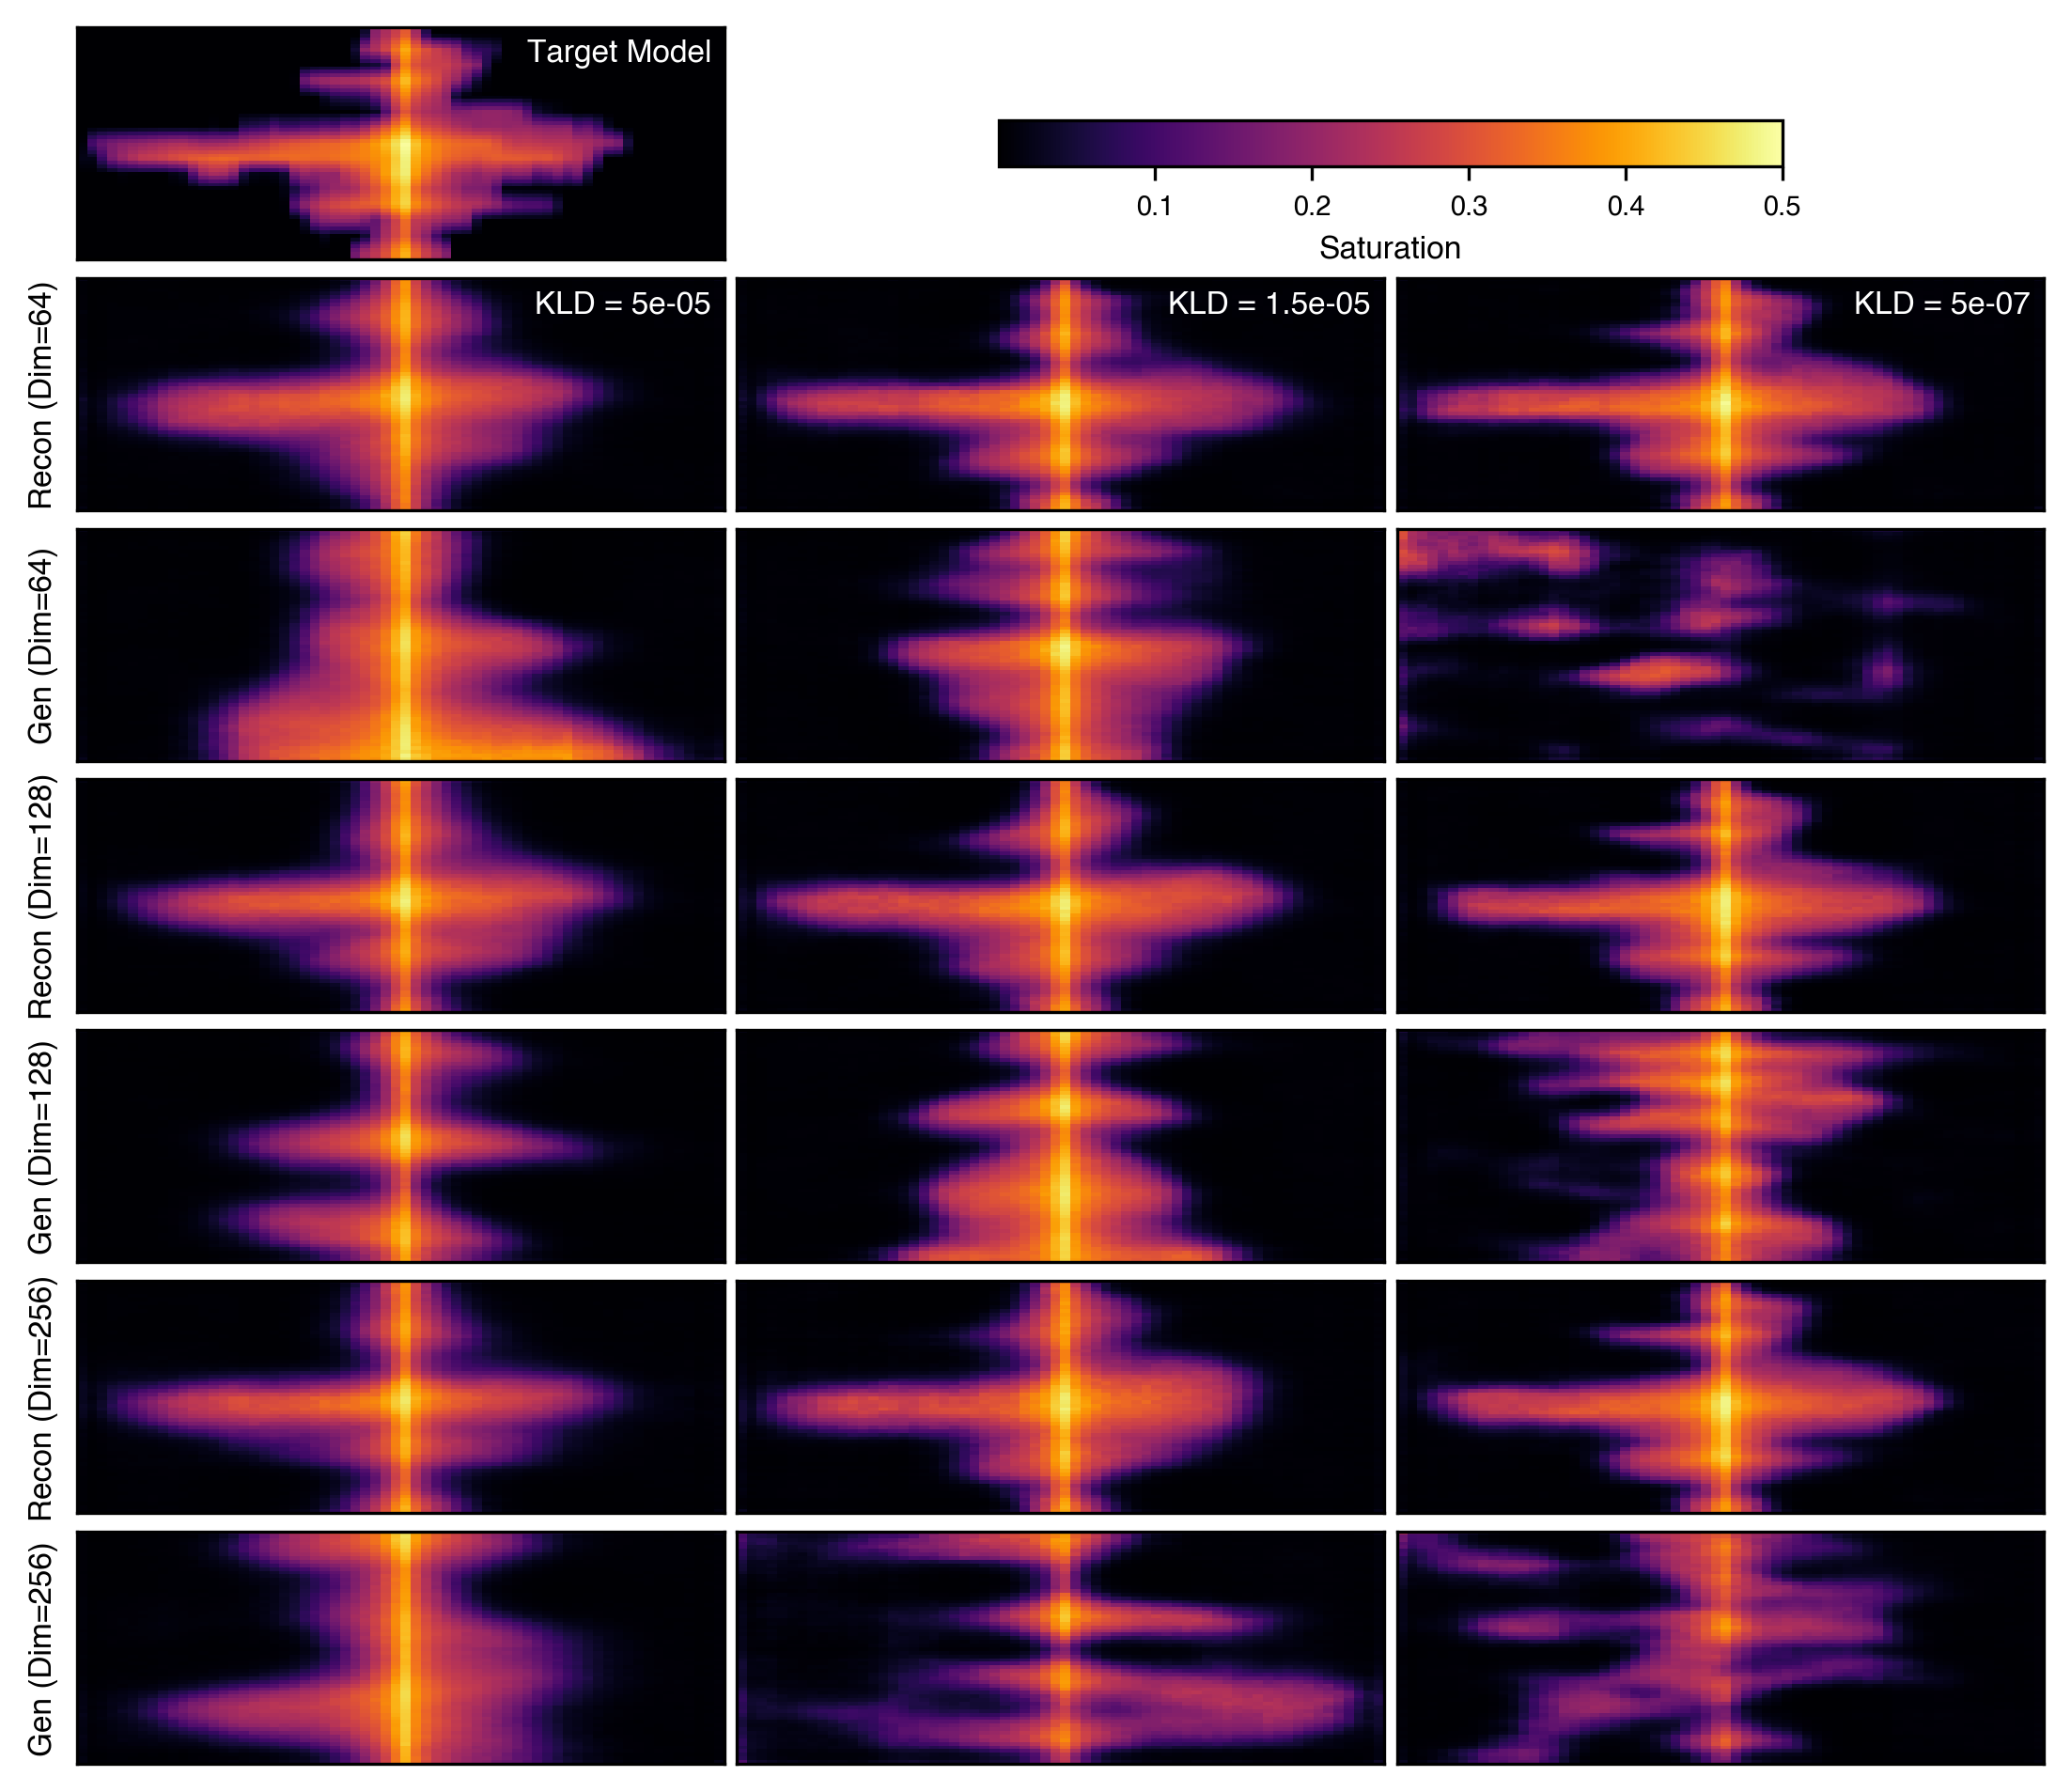

In [72]:
nrows = 1 + 2 * len(latent_dims)
ncols = len(kld_weights)

fig = plt.figure(figsize=(9, 8), dpi=300)
gs = gridspec.GridSpec(nrows, ncols, figure=fig, hspace=0.08, wspace=0.02)

true_np = CO2_true.detach().cpu().numpy().squeeze()

# ------------------ Target Model ------------------
ax00 = fig.add_subplot(gs[0, 0])
im = ax00.imshow(true_np, cmap=cmap, vmin=0, vmax=0.5, aspect="auto")
ax00.set_xticks([])
ax00.set_yticks([])
ax00.text(0.98, 0.95, "Target Model", transform=ax00.transAxes, fontsize=8, color="white", ha="right", va="top")

# ------------------ Colorbar ------------------
cax_cell = fig.add_subplot(gs[0, 1:])
cax_cell.set_xticks([])
cax_cell.set_yticks([])

for spine in cax_cell.spines.values():
    spine.set_visible(False)

cax = inset_axes(cax_cell, width="60%", height="20%", loc="center")

cb = fig.colorbar(im, cax=cax, orientation="horizontal")
cb.ax.tick_params(labelsize=7)
cb.ax.locator_params(nbins=4)
cb.set_label("Saturation", fontsize=8, labelpad=4)
cb.set_ticks([0.1, 0.2, 0.3, 0.4, 0.5])

# ------------------ SWEEP ------------------
for i, latent_dim in enumerate(latent_dims):

    recon_row = 1 + 2 * i
    gen_row = recon_row + 1

    for j, kld_weight in enumerate(kld_weights):

        checkpoint_path = path / f"VAE/vae_latent_dim{latent_dim}_kld_weight{kld_weight}.pth"

        model = VanillaVAE(in_channels=in_channels, latent_dim=latent_dim).to(device)
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        model.eval()

        z = torch.randn(1, model.latent_dim).to(device)

        with torch.no_grad():
            CO2_gene = model.decode(z).detach().cpu().numpy().squeeze()
            CO2_recon = model.generate(CO2_true).detach().cpu().numpy().squeeze()

        # -------- Reconstruction --------
        ax_recon = fig.add_subplot(gs[recon_row, j])
        ax_recon.imshow(CO2_recon, cmap=cmap, vmin=0, vmax=0.5, aspect="auto")
        ax_recon.set_xticks([])
        ax_recon.set_yticks([])

        if j == 0:
            ax_recon.text(-0.03, 0.5, f"Recon (Dim={latent_dim})", transform=ax_recon.transAxes, fontsize=8, rotation=90, ha="right", va="center")

        # KLD labels in first reconstruction row
        if i == 0:
            ax_recon.text(0.98, 0.95, f"KLD = {kld_weight:g}", transform=ax_recon.transAxes, fontsize=8, color="white", ha="right", va="top")

        # -------- Generative --------
        ax_gene = fig.add_subplot(gs[gen_row, j])
        ax_gene.imshow(CO2_gene, cmap=cmap, vmin=0, vmax=0.5, aspect="auto")
        ax_gene.set_xticks([])
        ax_gene.set_yticks([])

        if j == 0:
            ax_gene.text(-0.03, 0.5, f"Gen (Dim={latent_dim})", transform=ax_gene.transAxes, fontsize=8, rotation=90, ha="right", va="center")

plt.tight_layout()
plt.savefig(f"figures_revision/vae_exps_sample{idx}.png", bbox_inches="tight")
plt.show()